# Analysis of tissue composition of archetypes


This code calculates the relative distance of each cell within the gene expression space to all archetypes.
Identifies the archetype to which each cell is most closely associated.
It generates plots that describe the relationships between tissues and archetypes, based on these associations.

 Input Files:
1. arcOrig.mat : Contains the coordinates of the archetypes in the original gene expression space. ("Mac_5_arcOrig.mat")
2. Gene Expression Matrix: The cells in the original gene space, the input of the ParTI.. ("HighV_logZ.csv" or adata like "High_Var_Norm_macro.h5ad")
3. Metadata File : Contains information on the tissue identity of each cell. ("macro_meta.csv" or adata.obs)

In [2]:
import anndata as ad
import pandas as pd
import numpy as np
from scipy.io import loadmat
import os
import pathlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output, Markdown
import re
from ipywidgets import interact
import ipywidgets as widgets
from sklearn.decomposition import PCA
from adjustText import adjust_text

# Enable interactive matplotlib backend for Jupyter
%matplotlib inline

# Define Base Directory for Data
import os
BASE_DIR = pathlib.Path(os.getcwd()).resolve().parents[1]

# Define Directories
PROJECT_DIR = BASE_DIR
FIG6_DIR = PROJECT_DIR / 'Data' / '06_CrossSpecies' / 'ParTI_results'
RESULTS_DIR = PROJECT_DIR / 'Results' / 'Figure_6_Composition'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## functions

### calculate function

In [3]:
def calculate_archetype_weights(point, archetypes):
    """
    Calculate the weights of a point relative to a set of archetypes.
    
    Args:
        point (np.array): Gene expression matrix.
        archetypes (np.array): Matrix of archetype coordinates.
        
    Returns:
        np.array: Normalized weights summing to 1.
    """
    if archetypes.shape[1] != len(point):
        raise ValueError(
            f"Mismatch in dimensions: archetypes have {archetypes.shape[1]} features, "
            f"but point has {len(point)} features."
        )

    # Extend archetypes and point for homogeneous coordinates
    extended_archetypes = np.hstack((archetypes, np.ones((archetypes.shape[0], 1))))
    extended_point = np.append(point, 1)

    # Compute A and b
    A = np.dot(extended_archetypes, extended_archetypes.T)
    b = np.dot(extended_archetypes, extended_point)

    # Solve for weights
    weights = np.linalg.solve(A, b)
    return weights / np.sum(weights) 

def process_weights(gene_expression, archetypes, metadata, tissue_col, archetype_prefix):
    """
    Process gene expression data to calculate archetype weights and format into a DataFrame.
    """
    # Calculate weights
    weights_np = np.apply_along_axis(
        calculate_archetype_weights,
        1,
        np.asarray(gene_expression),
        archetypes
    )
    
    # Create DataFrame
    weights_df = pd.DataFrame(
        weights_np, 
        columns=[f"{archetype_prefix}_{i+1}" for i in range(archetypes.shape[0])],
        index=metadata.index
    )
    
    weights_df.columns = [f"Archetype_{i+1}" for i in range(archetypes.shape[0])]
    
    weights_df['Max_Weight'] = weights_df.max(axis=1)
    weights_df['Dominant_Archetype'] = weights_df.idxmax(axis=1)
    
    # This assumes metadata and weights_df are row-aligned, which they are by construction.
    weights_df['Tissue'] = metadata[tissue_col].values
    
    return weights_df


In [3]:
def _extract_archetype_int(value) -> int:
    if pd.isna(value):
        return 0

    if isinstance(value, (int, np.integer, float, np.floating)):
        return int(value)

    value_str = str(value).strip()

    if value_str == "-1":
        return -1

    m = re.search(r"(?:archetype|arc|am|af|ae)[ _]?(\d+)", value_str, re.IGNORECASE)
    return int(m.group(1)) if m else 0

def calculate_tables(df: pd.DataFrame, threshold: float = 0.5, generalist_threshold: float = 0.3):
    """
    Returns normalized summary DataFrames for plotting.

    Classification:
    - Max_Weight >= threshold: assigned to dominant archetype
    - Max_Weight < generalist_threshold: generalist (archetype 0)
    - generalist_threshold <= Max_Weight < threshold: discarded
    """
    df = df.copy()

    # Normalize tissue names
    df["Tissue"] = (
        df["Tissue"]
        .astype(str)
        .str.strip()
        .str.replace("_", " ", regex=False)
    )

    df["Tissue"] = df["Tissue"].replace({
        "Small intestine": "Small Intestine",
        "Large intestine": "Large Intestine",
        "Bone Marrow": "Bone marrow",
        "Limb muscle": "Limb Muscle",
        "Mammary gland": "Mammary Gland",
    })

    # Assign archetypes / generalists / discarded cells
    df["archetype_raw"] = np.where(
        df["Max_Weight"] >= threshold,
        df["Dominant_Archetype"],
        np.where(df["Max_Weight"] < 0.3, 0, -1)
    )

    # Convert labels to integer archetype ids
    df["archetype"] = df["archetype_raw"].map(_extract_archetype_int).astype(int)

    # Normalize by remaining tissue counts
    tissue_counts = df["Tissue"].value_counts().to_dict()

    def build_stats(group_col, value_col):
        rows = sorted(df[group_col].unique())
        cols = sorted(df[value_col].unique())

        idx = pd.MultiIndex.from_product([rows, cols], names=[group_col, value_col])

        counts = (
            df.groupby([group_col, value_col], observed=True)
            .size()
            .reindex(idx, fill_value=0)
            .reset_index(name="Count")
        )

        totals = counts["Tissue"].map(tissue_counts).fillna(0)

        counts["Adjusted_Count"] = np.where(
            totals > 0,
            (counts["Count"] * 1000) / totals,
            0
        )

        counts["Percentage"] = counts.groupby(group_col)["Adjusted_Count"].transform(
            lambda x: 100 * x / x.sum() if x.sum() > 0 else 0
        )

        return counts

    arch_summary = build_stats(group_col="archetype", value_col="Tissue")
    tissue_summary = build_stats(group_col="Tissue", value_col="archetype")

    return arch_summary, tissue_summary

In [4]:
def calculate_gini(df_input, threshold=0.5):
    """
    Calculates normalized Gini-Simpson Index (0 to 1 range).
    """
    arch_data, _ = calculate_tables(df_input, threshold)
    df_filtered = arch_data.copy()

    n_tissues = df_filtered["Tissue"].nunique()
    max_theoretical_gini = 1 - (1 / n_tissues)

    gini_scores = {}
    for arch_id in sorted(df_filtered["archetype"].unique()):
        subset = df_filtered[df_filtered["archetype"] == arch_id]
        proportions = subset["Percentage"] / 100.0
        raw_gini = 1 - (proportions ** 2).sum()
        gini_scores[arch_id] = raw_gini / max_theoretical_gini

    return pd.Series(gini_scores)

def run_pca_calculation(
    df_input,
    threshold=0.5,
    include_generalists=False,
    n_components=2
):
    """
    Performs PCA on tissue-by-archetype composition data.

    Rules:
    - Semi-specialists (-1) are always excluded from PCA.
    - Generalists (0) are included only if include_generalists=True.
    - After removing columns, each tissue is renormalized to sum to 1.
    """
    _, tissue_data = calculate_tables(df_input, threshold)

    pivot_df = (
        tissue_data
        .pivot(index="Tissue", columns="archetype", values="Percentage")
        .fillna(0)
    )

    # Convert percentages to fractions
    pivot_df = pivot_df / 100.0

    # Always remove semi-specialists from PCA
    if -1 in pivot_df.columns:
        pivot_df = pivot_df.drop(columns=[-1])

    # Remove generalists only if requested
    if not include_generalists and 0 in pivot_df.columns:
        pivot_df = pivot_df.drop(columns=[0])

    # Renormalize each tissue after filtering
    row_sums = pivot_df.sum(axis=1)
    pivot_df = pivot_df.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

    # PCA cannot have more components than min(n tissues, n features)
    max_components = min(pivot_df.shape[0], pivot_df.shape[1])
    n_components = min(n_components, max_components)

    pca = PCA(n_components=n_components)
    coords = pca.fit_transform(pivot_df)
    var_exp = pca.explained_variance_ratio_ * 100

    return coords, var_exp, pivot_df.index

### visualization functions

In [ ]:
TARGET_TISSUE_ORDER = [
    "Pancreas",
    "Heart",
    "Kidney",
    "Thymus",
    "Liver",
    "Lung",
    "Spleen",
    "Fat",
    "Trachea",
    "Small Intestine",
    "Small_intestine",
    "Tongue",
    "Bladder",
    "Large Intestine",
    "Large_intestine",
    "Skin",
    "Marrow",
    "Bone marrow",
    "Limb Muscle",
    "Limb muscle",
    "Muscle",
    "Mammary Gland",
    "Mammary gland",
    "Mammary",
    "Stomach",
]

TISSUE_PALETTE = {
    "Bladder": "#3953A4",
    "Fat": "#ED2024",
    "Heart": "#6ABD45",
    "Kidney": "#0F1031",

    "Large Intestine": "#E03F97",
    "Large_intestine": "#E03F97",

    "Liver": "#1F5429",
    "Lung": "#FED304",
    "Pancreas": "#4996D2",
    "Skin": "#9A4D42",

    "Small Intestine": "#DF7D26",
    "Small_intestine": "#DF7D26",

    "Spleen": "#714EA0",
    "Thymus": "#1E9698",
    "Tongue": "#E3AFD1",
    "Trachea": "#A93493",

    # aliases for the exact names appearing in your plot
    "Marrow": "#A781BA",
    "Bone marrow": "#A781BA",
    "Bone_Marrow": "#A781BA",

    "Limb Muscle": "#18BDC2",
    "Limb muscle": "#18BDC2",

    "Mammary Gland": "#C29A2D",
    "Mammary gland": "#C29A2D",
    "Mammary": "#C29A2D",

    "Stomach": "#C49A6C",
    "Muscle": "#5C8A00",
}

ARCHETYPE_PALETTE = {
    1: "#FFFF33",
    2: "#377EB8",
    3: "#4DAF4A",
    4: "#E41A1C",
    5: "#984EA3",
    6: "#FF7F00",
    0: "#808080",
}

# Add lowercase aliases so "heart" matches "Heart", etc.
TISSUE_PALETTE.update({
    k.lower(): v for k, v in TISSUE_PALETTE.items()
})

# Specific alias: colon should use Large Intestine color
TISSUE_PALETTE["colon"] = TISSUE_PALETTE["Large Intestine"]

In [8]:
def _archetype_label(arch_id, prefix="AM"):
    """
    Format archetype labels for plots.
    """
    arch_id = int(arch_id)

    if arch_id == -1:
        return "Semi-specialists"
    if arch_id == 0:
        return "Generalists"

    return f"{prefix}{arch_id}"


def _threshold_tag(threshold):
    """
    Convert threshold value into filename-safe tag.
    Example: 0.5 -> thr0p50
    """
    return f"thr{threshold:.2f}".replace(".", "p")


def _prepare_save_path(save_path):
    """
    Prepare save directory.
    If save_path is None, save to current working directory.
    """
    if save_path is None:
        save_path = pathlib.Path(".")
    else:
        save_path = pathlib.Path(save_path)

    save_path.mkdir(parents=True, exist_ok=True)
    return save_path


def plot_tissues(
    df_input,
    threshold=0.5,
    prefix="AM",
    save_path=None,
    include_generalists=True
):
    """
    Plot tissue composition per archetype.
    Saves:
    - PDF figure
    - CSV pivot table used for plotting
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    arch_data, _ = calculate_tables(df_input, threshold)
    plot_data = arch_data.copy()

    if not include_generalists:
        plot_data = plot_data[plot_data["archetype"] != 0].copy()

    pivot_df = (
        plot_data
        .pivot(index="archetype", columns="Tissue", values="Percentage")
        .fillna(0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(5, 6))
    seen_tissues = set()

    for x_pos, (arch_id, row) in enumerate(pivot_df.iterrows()):
        sorted_row = row.sort_values(ascending=False)
        current_bottom = 0

        for tissue, pct in sorted_row.items():
            if pct > 0:
                ax.bar(
                    x=x_pos,
                    height=pct,
                    bottom=current_bottom,
                    color=TISSUE_PALETTE.get(tissue, "#999999"),
                    edgecolor="black",
                    linewidth=0.5,
                    width=0.85
                )
                current_bottom += pct
                seen_tissues.add(tissue)

    ax.set_title(f"Thresh: {threshold:.2f}", fontsize=12)
    ax.set_ylabel("Tissue composition (%)", fontsize=12)

    ax.set_xticks(range(len(pivot_df)))
    ax.set_xticklabels(
        [_archetype_label(i, prefix=prefix) for i in pivot_df.index],
        fontsize=11,
        rotation=45,
        ha="right"
    )

    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ordered_seen = [t for t in TARGET_TISSUE_ORDER if t in seen_tissues]
    leftovers = sorted([t for t in seen_tissues if t not in ordered_seen])
    legend_tissues = ordered_seen + leftovers

    patches = [
        mpatches.Patch(
            color=TISSUE_PALETTE.get(t, "#999999"),
            label=t.replace("_", " ")
        )
        for t in legend_tissues
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False,
        title="Tissue"
    )

    plt.tight_layout()

    suffix = "with_generalists" if include_generalists else "no_generalists"

    pdf_path = save_path / f"tissue_composition_{prefix}_{tag}_{suffix}.pdf"
    csv_path = save_path / f"tissue_composition_{prefix}_{tag}_{suffix}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")
    pivot_df.to_csv(csv_path)

    display(fig)
    plt.close(fig)

    return pivot_df

def plot_archetypes(
    df_input,
    threshold=0.5,
    prefix="AM",
    save_path=None,
    include_generalists=True,
    hide_semi_specialists=True
):
    """
    Plot archetype composition per tissue.

    Logic:
    - archetype = -1: Semi-specialists
    - archetype = 0: Generalists
    - archetype > 0: Specialists assigned to AMs

    By default:
    - Semi-specialists are hidden
    - Visible categories are renormalized to 100%
    - PDF and CSV are saved
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    _, tissue_data = calculate_tables(df_input, threshold)
    plot_data = tissue_data.copy()

    # Hide semi-specialists before plotting
    if hide_semi_specialists:
        plot_data = plot_data[plot_data["archetype"] != -1].copy()

    # Optional: hide generalists too
    if not include_generalists:
        plot_data = plot_data[plot_data["archetype"] != 0].copy()

    pivot_df = (
        plot_data
        .pivot(index="Tissue", columns="archetype", values="Percentage")
        .fillna(0)
    )

    # Option B:
    # After hiding semi-specialists, renormalize visible categories to 100%
    pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
    pivot_df = pivot_df.fillna(0)

    existing_order = [t for t in TARGET_TISSUE_ORDER if t in pivot_df.index]
    leftovers = [t for t in pivot_df.index if t not in existing_order]
    pivot_df = pivot_df.reindex(existing_order + leftovers)

    fig, ax = plt.subplots(figsize=(10, 5))
    bottoms = np.zeros(len(pivot_df))

    arch_cols = sorted(pivot_df.columns)

    for arch_id in arch_cols:
        arch_id = int(arch_id)

        values = pivot_df[arch_id].values
        label = _archetype_label(arch_id, prefix=prefix)
        color = ARCHETYPE_PALETTE.get(arch_id, "#999999")

        ax.bar(
            pivot_df.index,
            values,
            bottom=bottoms,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            width=0.8
        )

        bottoms += values

    ax.set_title(f"Thresh: {threshold:.2f}", fontsize=12)
    ax.set_ylabel("Archetype composition among visible cells (%)", fontsize=12)

    ax.set_xticks(range(len(pivot_df)))
    ax.set_xticklabels(
        pivot_df.index,
        rotation=45,
        ha="right",
        fontsize=11
    )

    ax.set_ylim(0, 100)
    ax.set_xlim(-0.6, len(pivot_df) - 0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        reversed(handles),
        reversed(labels),
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()

    suffix_parts = []

    if include_generalists:
        suffix_parts.append("with_generalists")
    else:
        suffix_parts.append("no_generalists")

    if hide_semi_specialists:
        suffix_parts.append("semi_hidden_renorm")
    else:
        suffix_parts.append("with_semi")

    suffix = "_".join(suffix_parts)

    pdf_path = save_path / f"archetype_composition_{prefix}_{tag}_{suffix}.pdf"
    csv_path = save_path / f"archetype_composition_{prefix}_{tag}_{suffix}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")
    pivot_df.to_csv(csv_path)

    display(fig)
    plt.close(fig)

    return pivot_df


def plot_gini(
    df_input,
    threshold=0.5,
    prefix="AM",
    save_path=None,
    include_generalists=True
):
    """
    Plot Gini-Simpson index per archetype.
    Saves:
    - PDF figure
    - CSV values used for plotting
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    gini_scores = calculate_gini(df_input, threshold)

    if not include_generalists and 0 in gini_scores.index:
        gini_scores = gini_scores.drop(index=0)

    fig, ax = plt.subplots(figsize=(4, 5))

    ax.bar(
        range(len(gini_scores)),
        gini_scores.values,
        color="#D3D3D3",
        edgecolor="black",
        linewidth=1.0,
        width=0.7
    )

    ax.set_ylabel("Gini-Simpson index", fontsize=12)
    ax.set_ylim(0, 1.05)

    ax.set_xticks(range(len(gini_scores)))
    ax.set_xticklabels(
        [_archetype_label(i, prefix=prefix) for i in gini_scores.index],
        fontsize=11,
        rotation=45,
        ha="right"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    suffix = "with_generalists" if include_generalists else "no_generalists"

    pdf_path = save_path / f"gini_index_{prefix}_{tag}_{suffix}.pdf"
    csv_path = save_path / f"gini_index_{prefix}_{tag}_{suffix}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")

    gini_df = (
        gini_scores
        .rename("Gini_Simpson")
        .reset_index()
        .rename(columns={"index": "archetype"})
    )
    gini_df["label"] = gini_df["archetype"].map(lambda x: _archetype_label(x, prefix=prefix))
    gini_df.to_csv(csv_path, index=False)

    display(fig)
    plt.close(fig)

    return gini_scores


def draw_pca_plot(
    coords,
    var_exp,
    tissue_names,
    threshold,
    save_path=None,
    prefix="AM",
    cell_type_prefix="celltype",
    include_generalists=False
):
    """
    Draw PCA plot.
    Saves:
    - PDF figure
    - CSV PCA coordinates used for plotting
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c="black",
        s=40
    )

    texts = []
    for i, txt in enumerate(tissue_names):
        texts.append(
            ax.text(
                coords[i, 0],
                coords[i, 1],
                txt,
                fontsize=11
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

    ax.set_xlabel(f"PC1 ({var_exp[0]:.0f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({var_exp[1]:.0f}%)", fontsize=12)
    ax.set_title(f"Thresh: {threshold:.2f}", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()

    suffix = "with_generalists" if include_generalists else "no_generalists"

    pdf_path = save_path / f"pca_plot_{cell_type_prefix}_{tag}_{suffix}.pdf"
    csv_path = save_path / f"pca_plot_{cell_type_prefix}_{tag}_{suffix}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")

    pca_df = pd.DataFrame({
        "Tissue": list(tissue_names),
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "PC1_variance_percent": var_exp[0],
        "PC2_variance_percent": var_exp[1],
        "threshold": threshold,
        "include_generalists": include_generalists,
    })

    pca_df.to_csv(csv_path, index=False)

    display(fig)
    plt.close(fig)

    return pca_df


def interactive_pca_wrapper(
    df_input,
    threshold=0.5,
    save_path=None,
    cell_type_prefix="celltype",
    include_generalists=False
):
    """
    Run PCA calculation and plot PCA.
    Saves:
    - PDF PCA figure
    - CSV PCA coordinates
    """
    coords, var, names = run_pca_calculation(
        df_input,
        threshold=threshold,
        include_generalists=include_generalists
    )

    pca_df = draw_pca_plot(
        coords=coords,
        var_exp=var,
        tissue_names=names,
        threshold=threshold,
        save_path=save_path,
        cell_type_prefix=cell_type_prefix,
        include_generalists=include_generalists
    )

    return pca_df

## macrophage data

### Load Data

In [ ]:
# Load Macrophage Data
mac_path = FIG6_DIR / 'macro_mice'
adata_path = FIG6_DIR / 'macro_mice' / 'droplet_6_5.h5ad'

adata = ad.read_h5ad(adata_path)
gene_expression_data = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
archetypes_data = loadmat(FIG6_DIR / 'macro_mice' / 'droplet_z_arcOrig.mat')['arcOrig']

metadata = adata.obs


In [10]:
macrophage_weights = process_weights(
    gene_expression_data,
    archetypes_data,
    metadata,
    'tissue',
    'Archetype'
)


### calculate weights


In [5]:
macrophage_weights = process_weights(
    gene_expression_data,
    archetypes_data,
    metadata,
    'tissue',
    'Archetype'
)


In [6]:
macrophage_weights.head()

,Archetype_1,Archetype_2,Archetype_3,Archetype_4,Archetype_5,Max_Weight,Dominant_Archetype,Tissue
Kidney-10X_P4_5_AACCGCGAGGATATAC,0.115227,0.324870,0.318809,0.201544,0.039550,0.324870,Archetype_2,Kidney
Kidney-10X_P4_5_ACACCAACACGTAAGG,0.135298,0.291982,0.329012,0.230666,0.013042,0.329012,Archetype_3,Kidney
Kidney-10X_P4_5_ACGATACTCCAAGTAC,0.127893,0.256691,0.332988,0.219666,0.062762,0.332988,Archetype_3,Kidney
Kidney-10X_P4_5_ACTGATGTCTAGCACA,0.106164,0.293990,0.279982,0.298941,0.020923,0.298941,Archetype_4,Kidney
Kidney-10X_P4_5_ACTTACTCATAGACTC,0.123918,0.241042,0.344554,0.237605,0.052882,0.344554,Archetype_3,Kidney


In [7]:
macrophage_weights.to_csv(RESULTS_DIR / "macrophage_archetype_weights.csv", index=True)

###  Tissue composition plots

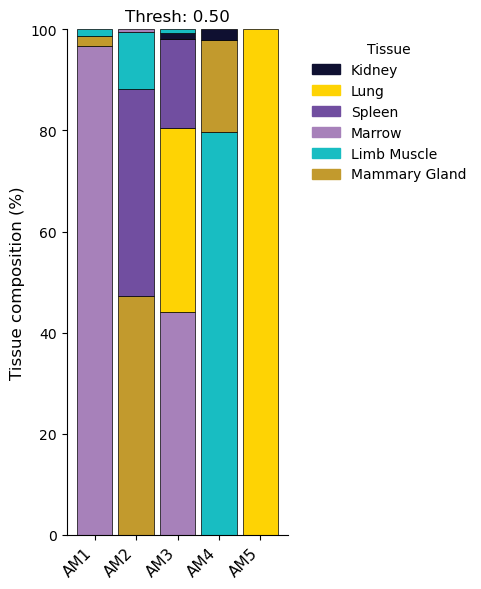

Tissue,Kidney,Limb Muscle,Lung,Mammary Gland,Marrow,Spleen
archetype,,,,,,
1,0.000000,1.240205,0.000000,2.047005,96.712790,0.000000
2,0.000000,11.236987,0.000000,47.295026,0.576496,40.891491
3,1.131952,0.768769,36.292824,0.000000,44.173373,17.633082
4,2.044745,79.618509,0.000000,18.336746,0.000000,0.000000
5,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000


In [52]:
plot_tissues(macrophage_weights,threshold=0.5, prefix='AM', save_path=RESULTS_DIR)


In [18]:
RESULTS_DIR 

WindowsPath('C:/Users/walfi/Desktop/cross_tissue_support_programs/Results/Figure_6_Composition')

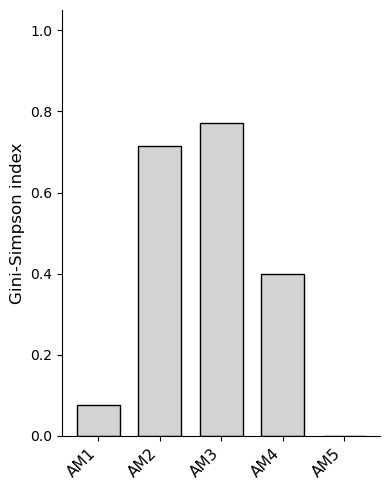

1    7.690896e-02
2    7.157357e-01
3    7.702495e-01
4    3.984571e-01
5   -5.329071e-16
dtype: float64

In [19]:
plot_gini(macrophage_weights, threshold=0.5, prefix='AM', save_path=RESULTS_DIR)


In [20]:
macrophage_weights

,Archetype_1,Archetype_2,Archetype_3,Archetype_4,Archetype_5,Max_Weight,Dominant_Archetype,Tissue
Kidney-10X_P4_5_AACCGCGAGGATATAC,0.115227,0.324870,0.318809,0.201544,0.039550,0.324870,Archetype_2,Kidney
Kidney-10X_P4_5_ACACCAACACGTAAGG,0.135298,0.291982,0.329012,0.230666,0.013042,0.329012,Archetype_3,Kidney
Kidney-10X_P4_5_ACGATACTCCAAGTAC,0.127893,0.256691,0.332988,0.219666,0.062762,0.332988,Archetype_3,Kidney
Kidney-10X_P4_5_ACTGATGTCTAGCACA,0.106164,0.293990,0.279982,0.298941,0.020923,0.298941,Archetype_4,Kidney
Kidney-10X_P4_5_ACTTACTCATAGACTC,0.123918,0.241042,0.344554,0.237605,0.052882,0.344554,Archetype_3,Kidney
...,...,...,...,...,...,...,...,...
Spleen-10X_P7_6_TTGGCAATCTGCTGCT,0.157740,0.531064,0.231319,0.060111,0.019766,0.531064,Archetype_2,Spleen
Spleen-10X_P7_6_TTTACTGCAATGCCAT,0.230040,0.511867,0.191108,-0.012330,0.079315,0.511867,Archetype_2,Spleen
Spleen-10X_P7_6_TTTATGCTCTGCTTGC,0.040069,0.694490,0.175609,0.086016,0.003816,0.694490,Archetype_2,Spleen
Spleen-10X_P7_6_TTTGGTTGTGGGTCAA,0.222678,0.454158,0.189052,-0.014138,0.148250,0.454158,Archetype_2,Spleen


### Archetype  composition per tissue

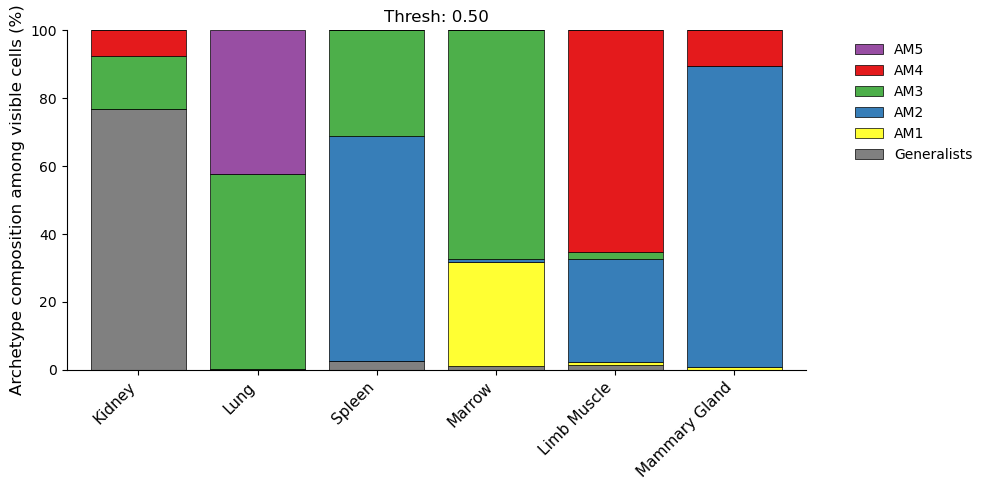

archetype,0,1,2,3,4,5
Tissue,,,,,,
Kidney,76.923077,0.000000,0.000000,15.384615,7.692308,0.000000
Lung,0.343053,0.000000,0.000000,57.289880,0.000000,42.367067
Spleen,2.702703,0.000000,66.066066,31.231231,0.000000,0.000000
Marrow,1.284109,30.497592,0.802568,67.415730,0.000000,0.000000
Limb Muscle,1.515152,0.757576,30.303030,2.272727,65.151515,0.000000
Mammary Gland,0.000000,0.869565,88.695652,0.000000,10.434783,0.000000


In [21]:
plot_archetypes(macrophage_weights, threshold=0.5, prefix='AM', save_path=RESULTS_DIR)


### PCA of archetype composition

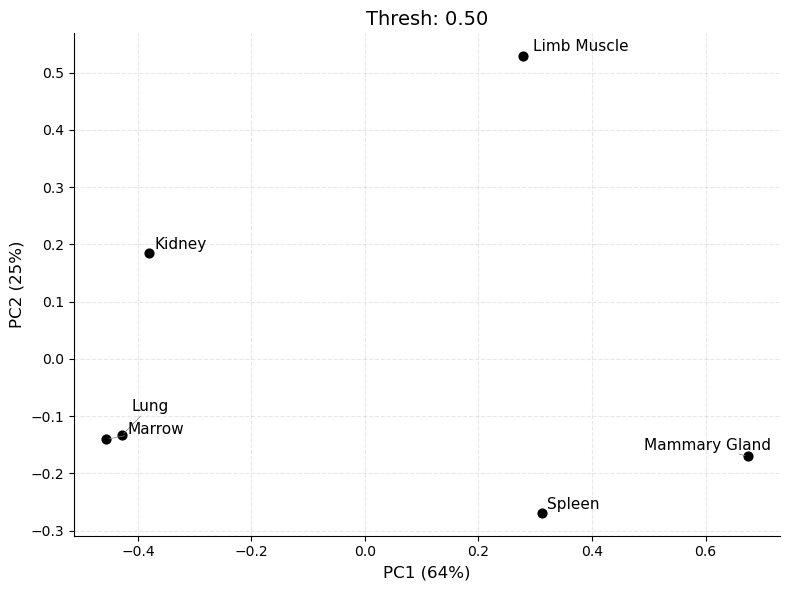

In [22]:
pca_df = interactive_pca_wrapper(
    macrophage_weights,
    threshold=0.5,
    save_path=RESULTS_DIR,
    cell_type_prefix="macrophage",
    include_generalists=False
)

## Fibroblast data

### load data

In [ ]:
# Load Fibroblast Data
fibro_path = r"C:\Users\walfi\Downloads\Mouse data-20260506T210549Z-3-001\Mouse data"
adata_fibro_path = r"C:\Users\walfi\Downloads\Mouse data-20260506T210549Z-3-001\Mouse data\fibro_mouse_raw.h5ad"

adata_fibro = ad.read_h5ad(adata_fibro_path)
gene_expression_fibro = adata_fibro.X if isinstance(adata_fibro.X, np.ndarray) else adata_fibro.X.toarray()
archetypes_data_fibro = loadmat(r"C:\Users\walfi\Downloads\Mouse data-20260506T210549Z-3-001\Mouse data\arcOrig.mat")['arcOrig']
Fibro_meta = adata_fibro.obs

## calculate weights

In [9]:

Fibro_meta = adata_fibro.obs
fibroblasts_weights = process_weights(
    gene_expression_fibro,
    archetypes_data_fibro,
    Fibro_meta,
    'tissue',
    'Archetype'
)


In [10]:
fibroblasts_weights.head()

,Archetype_1,Archetype_2,Archetype_3,Archetype_4,Archetype_5,Max_Weight,Dominant_Archetype,Tissue
0,0.204215,0.143409,0.532610,-0.052480,0.172246,0.532610,Archetype_3,fat
1,0.096170,-0.041299,0.553061,0.120653,0.271415,0.553061,Archetype_3,fat
2,0.094771,-0.036116,0.502091,0.136279,0.302975,0.502091,Archetype_3,fat
3,0.075685,0.094510,0.704679,0.031305,0.093822,0.704679,Archetype_3,fat
4,0.239401,0.065515,0.211751,0.252808,0.230525,0.252808,Archetype_4,fat


In [11]:
fibroblasts_weights.to_csv(RESULTS_DIR / "fibroblasts_archetype_weights.csv", index=True)

In [26]:
adata_fibro.obs['tissue'] = adata_fibro.obs["tissue"].replace({
    "intestine": "Large Intestine"
})

C:\Users\walfi\AppData\Local\Temp\ipykernel_45412\3150215579.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_fibro.obs['tissue'] = adata_fibro.obs["tissue"].replace({


## tissue composition plots

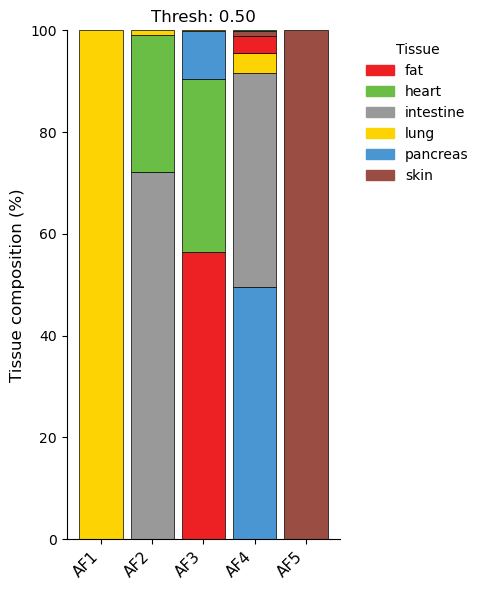

Tissue,fat,heart,intestine,lung,pancreas,skin
archetype,,,,,,
1,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
2,0.000000,26.956522,72.173913,0.869565,0.000000,0.000000
3,56.443024,33.972311,0.000000,0.106496,9.478168,0.000000
4,3.316327,0.127551,41.964286,3.954082,49.617347,1.020408
5,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000


In [53]:
plot_tissues(fibroblasts_weights, threshold=0.5, prefix='AF', save_path=RESULTS_DIR)


### Gini plots

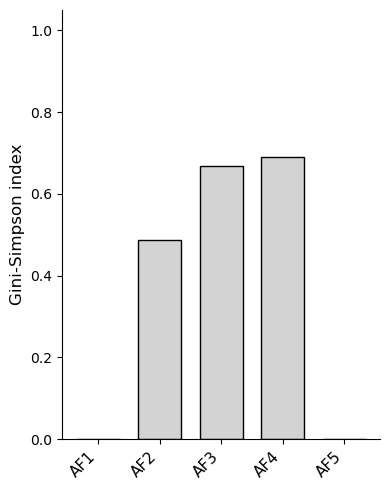

1    0.000000
2    0.487622
3    0.668426
4    0.689931
5    0.000000
dtype: float64

In [28]:
plot_gini(fibroblasts_weights, threshold=0.5, prefix='AF', save_path=RESULTS_DIR)


### archetype composition per tissue

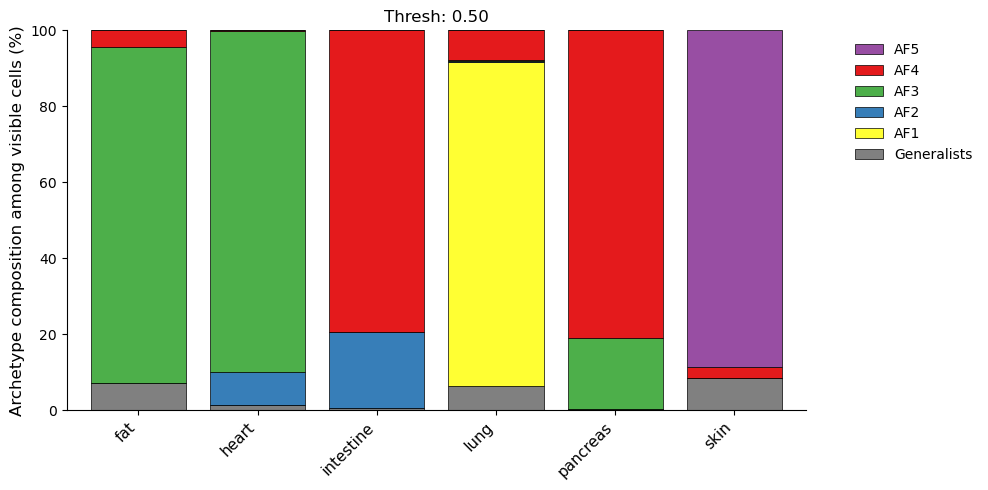

archetype,0,1,2,3,4,5
Tissue,,,,,,
fat,7.178631,0.000000,0.000000,88.480801,4.340568,0.000000
heart,1.404494,0.000000,8.707865,89.606742,0.280899,0.000000
intestine,0.483092,0.000000,20.048309,0.000000,79.468599,0.000000
lung,6.218905,85.572139,0.248756,0.248756,7.711443,0.000000
pancreas,0.416667,0.000000,0.000000,18.541667,81.041667,0.000000
skin,8.424908,0.000000,0.000000,0.000000,2.930403,88.644689


In [29]:
plot_archetypes(fibroblasts_weights, threshold=0.5, prefix='AF', save_path=RESULTS_DIR)


### PCA of archetype composition

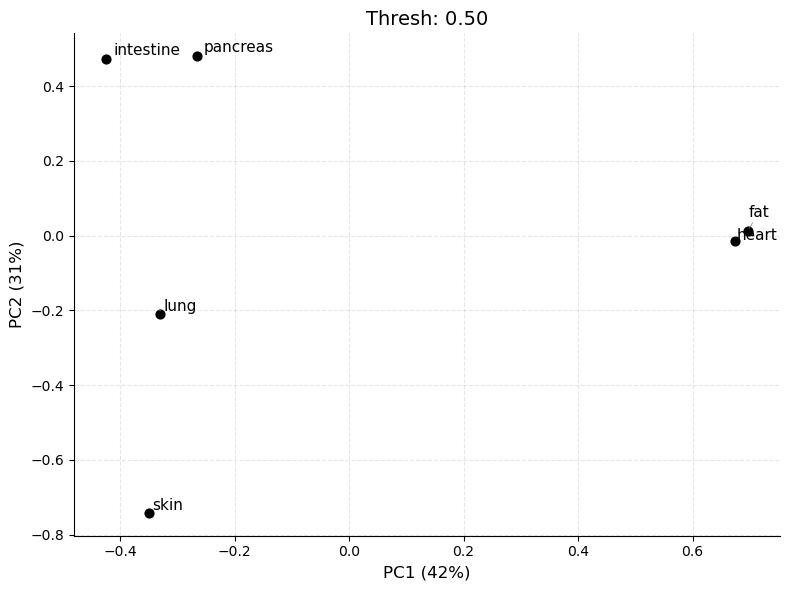

In [30]:
pca_df = interactive_pca_wrapper(
    fibroblasts_weights,
    threshold=0.5,
    save_path=RESULTS_DIR,
    cell_type_prefix="fibroblasts",
    include_generalists=False
)

## Endothelial data

### load data

In [ ]:


adata_endo_path = r'C:\Users\walfi\Downloads\drive-download-20260506T210703Z-3-001\endo_raw.h5ad'
adata_endo = ad.read_h5ad(adata_endo_path)
gene_expression_endo = adata_endo.X if isinstance(adata_endo.X, np.ndarray) else adata_endo.X.toarray()
archetypes_data_endo = loadmat(r"C:\Users\walfi\Downloads\drive-download-20260506T210703Z-3-001\EndoMs_arcOrig.mat")['arcOrig']
Endo_meta = adata_endo.obs

### calculate weights

In [13]:
endothelial_weights = process_weights(
    gene_expression_endo,
    archetypes_data_endo,
    Endo_meta,
    'tissue',
    'Archetype'
)


In [14]:
endothelial_weights.head()

,Archetype_1,Archetype_2,Archetype_3,Archetype_4,Archetype_5,Max_Weight,Dominant_Archetype,Tissue
Endo_cell_0,0.059905,0.689967,0.032316,0.104638,0.113174,0.689967,Archetype_2,colon
Endo_cell_1,0.091268,0.637356,0.043815,0.100869,0.126692,0.637356,Archetype_2,colon
Endo_cell_2,0.069760,0.625714,0.073743,0.097395,0.133388,0.625714,Archetype_2,colon
Endo_cell_3,0.079913,0.634305,0.002224,0.146271,0.137286,0.634305,Archetype_2,colon
Endo_cell_4,0.102218,0.103666,0.565792,0.079457,0.148868,0.565792,Archetype_3,colon


In [15]:
endothelial_weights.to_csv(RESULTS_DIR / "endothelial_archetype_weights.csv", index=True)

### tissue composition plots

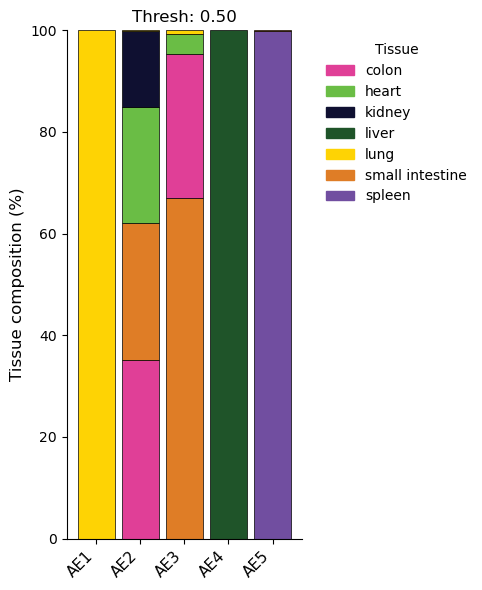

Tissue,colon,heart,kidney,liver,lung,small intestine,spleen
archetype,,,,,,,
1,0.000000,0.000000,0.000000,0.0,100.000000,0.000000,0.000000
2,35.056859,22.763467,15.020791,0.0,0.147263,27.011620,0.000000
3,28.233965,3.877469,0.000000,0.0,0.799563,67.089004,0.000000
4,0.000000,0.000000,0.000000,100.0,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.0,0.000000,0.228671,99.771329


In [54]:
 
plot_tissues(endothelial_weights, threshold=0.5, prefix='AE', save_path=RESULTS_DIR)


### Gini plots

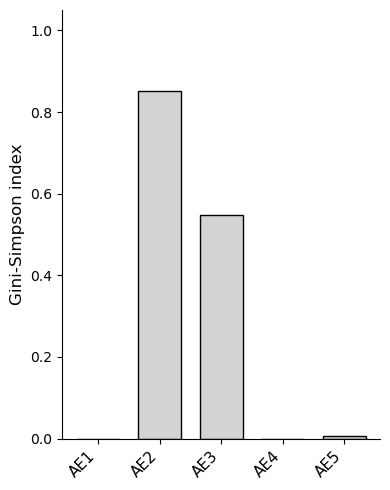

1    0.000000
2    0.851383
3    0.546727
4    0.000000
5    0.005323
dtype: float64

In [38]:
 
plot_gini(endothelial_weights, threshold=0.5, prefix='AE', save_path=RESULTS_DIR)


### archetype composition per tissue

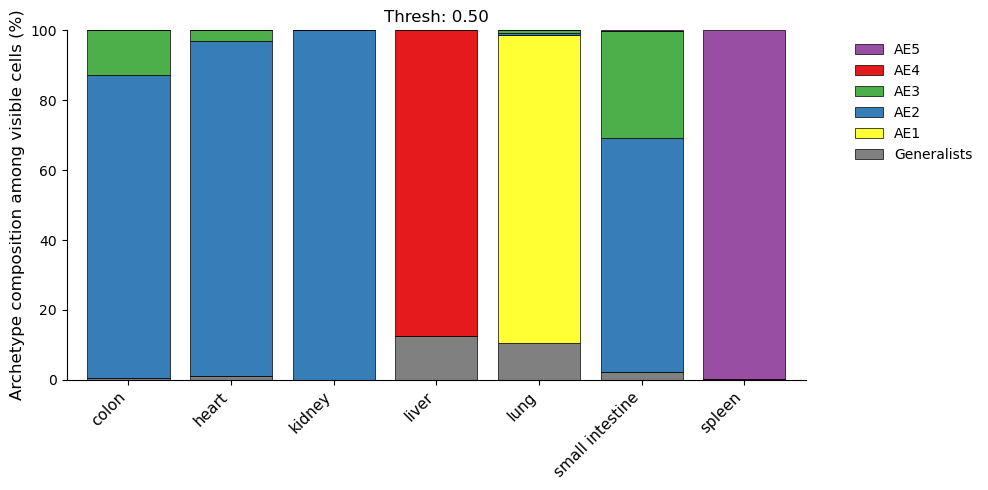

archetype,0,1,2,3,4,5
Tissue,,,,,,
colon,0.577201,0.000000,86.580087,12.842713,0.000000,0.000000
heart,1.127820,0.000000,95.864662,3.007519,0.000000,0.000000
kidney,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000
liver,12.669683,0.000000,0.000000,0.000000,87.330317,0.000000
lung,10.616438,88.013699,0.684932,0.684932,0.000000,0.000000
small intestine,2.137767,0.000000,66.983373,30.641330,0.000000,0.237530
spleen,0.138122,0.000000,0.000000,0.000000,0.000000,99.861878


In [39]:
 
plot_archetypes(endothelial_weights, threshold=0.5, prefix='AE', save_path=RESULTS_DIR)


### PCA of archetype composition

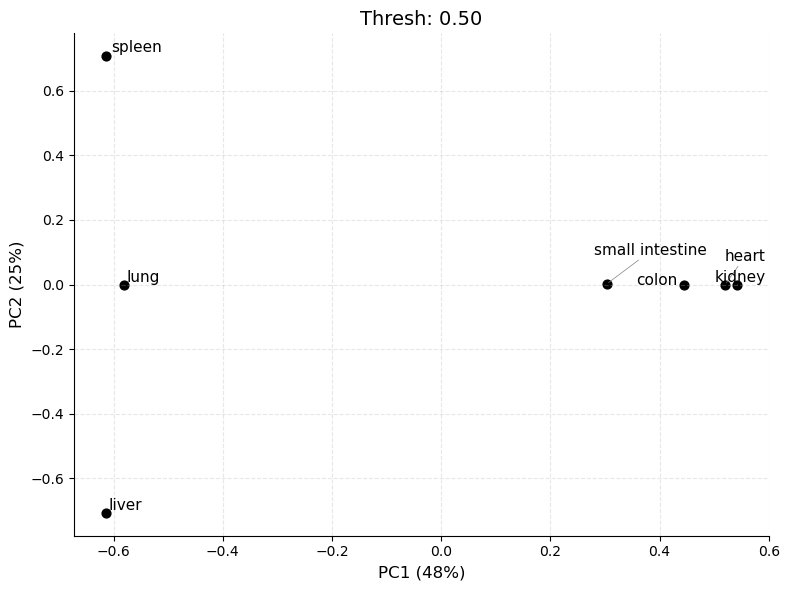

In [41]:
pca_df = interactive_pca_wrapper(
    endothelial_weights,
    threshold=0.5,
    save_path=RESULTS_DIR,
    cell_type_prefix="endothelial",
    include_generalists=False
)